# Assignment 1 — Robust comparison of 3 classifiers on 4 datasets

This notebook compares **SVM**, **Decision Tree**, and **K-NN** on the 4 provided datasets.

## Method
- For each dataset and classifier, perform **5-times 2-fold stratified cross-validation**
- Use **accuracy** as the evaluation metric
- Compute the **mean accuracy** over the 10 test folds
- Compare the 3 classifiers across the 4 datasets using the **Friedman test**

> Note: update the dataset folder path only if your `.mat` files are not in `../Datasets/`.

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.stats import friedmanchisquare, rankdata

from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
RANDOM_STATE = 42

## 1. Load the 4 datasets
Each dataset is assumed to be stored in a `.mat` file and the **last column is the class label**.

In [5]:
DATASET_DIR = Path("../Datasets")
DATASET_FILES = [
    DATASET_DIR/"dataset1.mat",
    DATASET_DIR/"dataset2.mat",
    DATASET_DIR/"dataset3.mat",
    DATASET_DIR/"dataset4.mat",
]

def mat_to_df(path):
    data = loadmat(path)
    keys = [k for k in data.keys() if not k.startswith("__")]
    if not keys:
        raise ValueError(f"No valid matrix found in {path}")
    arr = data[keys[0]]
    return pd.DataFrame(arr)

def split_xy(df):
    X = df.iloc[:, :-1].copy()
    y = df.iloc[:, -1].to_numpy().ravel()

    if y.dtype.kind in {"f", "i", "u"}:
        y = y.astype(int)
    else:
        y = pd.factorize(y)[0]

    return X, y

datasets = {}
for i, path in enumerate(DATASET_FILES, start=1):
    if not path.exists():
        raise FileNotFoundError(f"Dataset file not found: {path}")
    datasets[f"dataset{i}"] = mat_to_df(path)

for name, df in datasets.items():
    print(f"{name}: shape = {df.shape}")

dataset1: shape = (300, 2)
dataset2: shape = (300, 2)
dataset3: shape = (600, 2)
dataset4: shape = (600, 2)


Scatter Plot of the Datasets

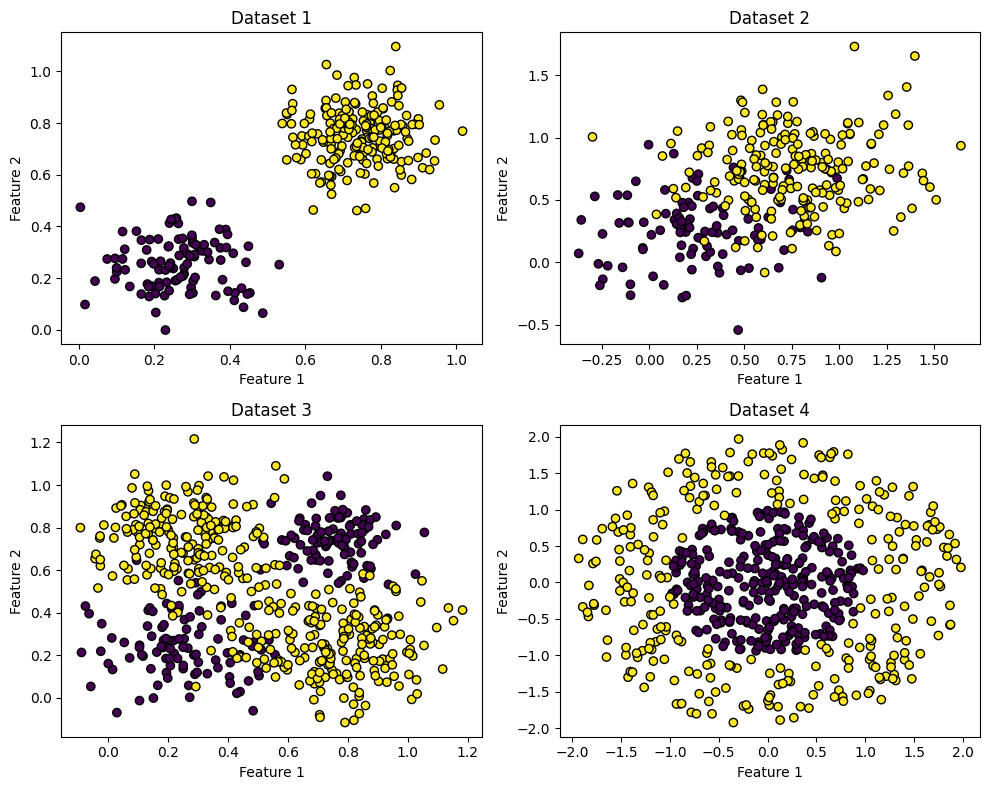

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))

for ndataset in range(1,5):

    dataset = loadmat(f"../Datasets/dataset{ndataset}.mat")

    data = dataset['data']
    labels = dataset['labels']

    ax = axes[(ndataset-1)//2, (ndataset-1)%2]

    ax.scatter(data[:,0], data[:,1], c=labels.flatten(), cmap='viridis', edgecolor='k')

    ax.set_title(f'Dataset {ndataset}')
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## 2. Define the 3 classifiers

This solution uses:
- **SVM** with RBF kernel
- **Decision Tree**
- **K-NN** with `k=5`

`StandardScaler` is applied to SVM and K-NN because these classifiers are sensitive to feature scale.

In [7]:
classifiers = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale"))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "K-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
}

classifiers

{'SVM': Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC())]),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'K-NN': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', KNeighborsClassifier())])}

## 3. Perform 5-times 2-fold stratified cross-validation
For each dataset and classifier:
- 2 folds
- repeated 5 times
- total = 10 test scores per classifier per dataset

In [5]:
rkf = RepeatedStratifiedKFold(
    n_splits=2,
    n_repeats=5,
    random_state=RANDOM_STATE
)

fold_results = []
mean_results = []

for dataset_name, df in datasets.items():
    X, y = split_xy(df)

    for clf_name, clf in classifiers.items():
        scores = []

        for fold_id, (train_idx, test_idx) in enumerate(rkf.split(X, y), start=1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = clone(clf)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            scores.append(acc)

            fold_results.append({
                "dataset": dataset_name,
                "classifier": clf_name,
                "fold": fold_id,
                "accuracy": acc
            })

        mean_results.append({
            "dataset": dataset_name,
            "classifier": clf_name,
            "mean_accuracy": np.mean(scores),
            "std_accuracy": np.std(scores, ddof=1),
            "min_accuracy": np.min(scores),
            "max_accuracy": np.max(scores)
        })

fold_df = pd.DataFrame(fold_results)
summary_df = pd.DataFrame(mean_results)
summary_df = summary_df.sort_values(["dataset", "mean_accuracy"], ascending=[True, False]).reset_index(drop=True)
summary_df

,dataset,classifier,mean_accuracy,std_accuracy,min_accuracy,max_accuracy
0,dataset1,SVM,0.990000,0.003514,0.986667,0.993333
1,dataset1,K-NN,0.990000,0.003514,0.986667,0.993333
2,dataset1,Decision Tree,0.980667,0.010634,0.960000,0.993333
3,dataset2,SVM,0.850000,0.003514,0.846667,0.853333
4,dataset2,K-NN,0.830667,0.021129,0.800000,0.860000
5,dataset2,Decision Tree,0.774000,0.031498,0.713333,0.813333
6,dataset3,SVM,0.986667,0.000000,0.986667,0.986667
7,dataset3,K-NN,0.986667,0.000000,0.986667,0.986667
8,dataset3,Decision Tree,0.962000,0.009584,0.943333,0.976667
9,dataset4,SVM,0.745000,0.001757,0.743333,0.746667


## 4. Mean accuracy table
This is the table used for the Friedman test: one mean score for each classifier on each dataset.

In [6]:
mean_table = summary_df.pivot(index="dataset", columns="classifier", values="mean_accuracy")
std_table = summary_df.pivot(index="dataset", columns="classifier", values="std_accuracy")

print("Mean accuracy table:")
display(mean_table)

print("\nStandard deviation table:")
display(std_table)

Mean accuracy table:


classifier,Decision Tree,K-NN,SVM
dataset,,,
dataset1,0.980667,0.990000,0.990000
dataset2,0.774000,0.830667,0.850000
dataset3,0.962000,0.986667,0.986667
dataset4,0.602333,0.694667,0.745000



Standard deviation table:


classifier,Decision Tree,K-NN,SVM
dataset,,,
dataset1,0.010634,0.003514,0.003514
dataset2,0.031498,0.021129,0.003514
dataset3,0.009584,0.000000,0.000000
dataset4,0.019184,0.020379,0.001757


# 6. Mean Accuracy Vs Dataset plot

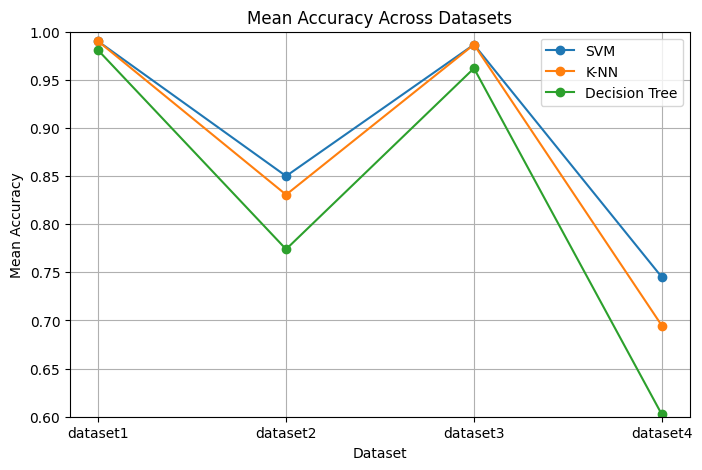

In [7]:
# plot of dataset vs mean accuracy for each classifier
plt.figure(figsize=(8,5))
datasets = mean_table.index.tolist()
svm = mean_table["SVM"].values
knn = mean_table["K-NN"].values
decision_tree = mean_table["Decision Tree"].values

plt.plot(datasets, svm, marker='o', label='SVM')
plt.plot(datasets, knn, marker='o', label='K-NN')
plt.plot(datasets, decision_tree, marker='o', label='Decision Tree')

plt.title("Mean Accuracy Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("Mean Accuracy")

plt.ylim(0.6, 1.0)

plt.grid(True)
plt.legend()

plt.show()

## 5. Average ranks across datasets
For each dataset, the best classifier gets rank 1.

In [8]:
rank_table = mean_table.apply(lambda row: rankdata(-row.values, method="average"), axis=1, result_type="expand")
rank_table.columns = mean_table.columns
rank_table.index = mean_table.index

avg_ranks = rank_table.mean(axis=0).sort_values()

print("Per-dataset ranks (lower is better):")
display(rank_table)

print("\nAverage ranks:")
display(avg_ranks.to_frame(name="average_rank"))

Per-dataset ranks (lower is better):


classifier,Decision Tree,K-NN,SVM
dataset,,,
dataset1,3.0,1.5,1.5
dataset2,3.0,2.0,1.0
dataset3,3.0,1.5,1.5
dataset4,3.0,2.0,1.0



Average ranks:


,average_rank
classifier,
SVM,1.25
K-NN,1.75
Decision Tree,3.00


## 6. Friedman test
The Friedman test checks whether the performance differences among the 3 classifiers are statistically significant across the 4 datasets.

In [9]:
statistic, p_value = friedmanchisquare(
    mean_table["SVM"].values,
    mean_table["Decision Tree"].values,
    mean_table["K-NN"].values
)

alpha = 0.05

print(f"Friedman statistic: {statistic:.6f}")
print(f"p-value: {p_value:.6f}")

if p_value < alpha:
    print(f"Result: reject H0 at alpha = {alpha}.")
    print("There is a statistically significant difference among the classifiers.")
else:
    print(f"Result: fail to reject H0 at alpha = {alpha}.")
    print("No statistically significant difference was detected among the classifiers.")

Friedman statistic: 7.428571
p-value: 0.024373
Result: reject H0 at alpha = 0.05.
There is a statistically significant difference among the classifiers.


## 7. classifier performance plot

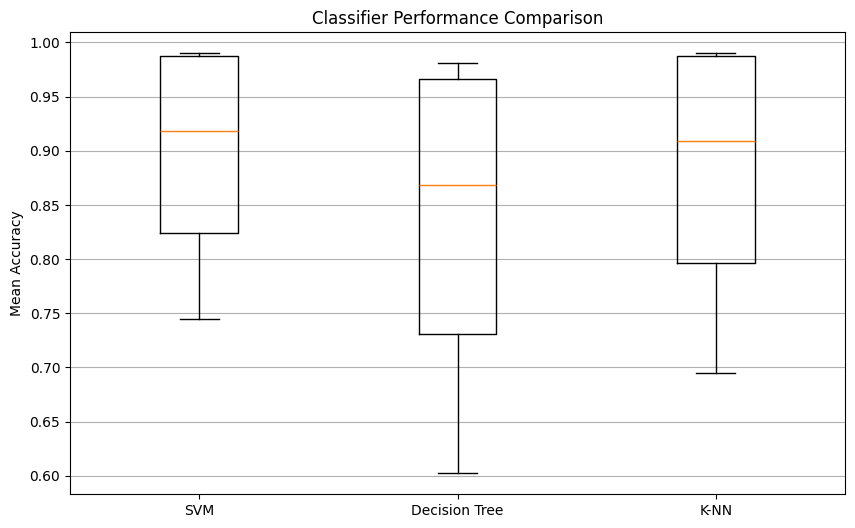

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.boxplot(
    [mean_table[clf] for clf in classifiers.keys()],
    labels=classifiers.keys()
)
plt.title("Classifier Performance Comparison")
plt.ylabel("Mean Accuracy")
plt.grid(axis="y")
plt.show()

# 8. Friedman critical difference diagram

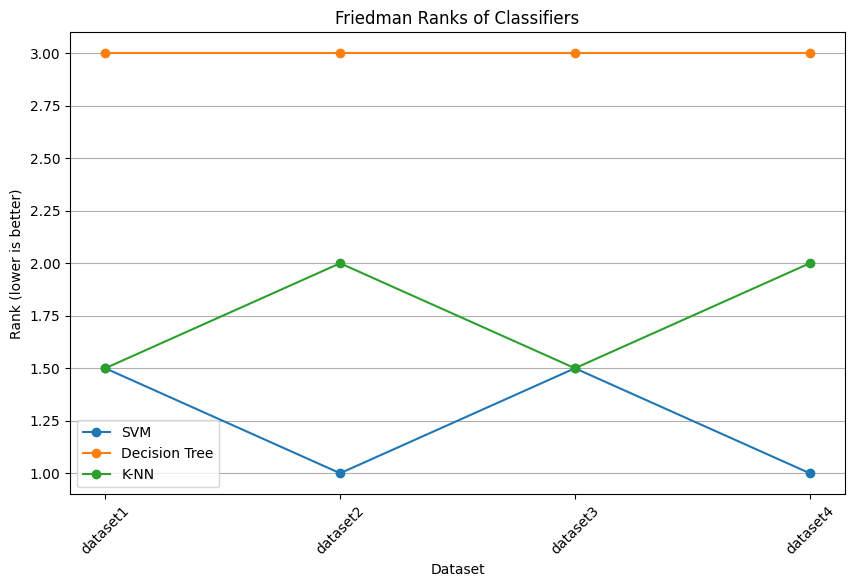

In [11]:
# Friedman difference diagram
plt.figure(figsize=(10, 6))
for clf in classifiers.keys():
    plt.plot(rank_table.index, rank_table[clf], marker="o", label=clf)
plt.title("Friedman Ranks of Classifiers")
plt.xlabel("Dataset")
plt.ylabel("Rank (lower is better)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y")
plt.show()